# Análisis y Predicción de Precios de Autos (Core)

**Objetivo**: Aplicar técnicas de regresión lineal, KNN y árboles de decisión para predecir precios de autos utilizando un dataset de Kaggle. Realizar un Análisis Exploratorio de Datos (EDA) completo y comparar el rendimiento de los modelos mediante benchmarking.

**Dataset**: [Automobile Dataset](https://www.kaggle.com/datasets/toramky/automobile-dataset)

**Descripción del Dataset**: Este conjunto de datos contiene información detallada sobre diferentes modelos de autos, incluyendo características técnicas y precios. El objetivo es predecir el precio de los autos basándose en sus características.

## Parte 1: Análisis Exploratorio de Datos (EDA)
### Carga y Exploración de Datos:

* Cargar el dataset y revisar la estructura básica.
* Descripción de las variables y su distribución.
* Detección y tratamiento de valores nulos.
* Identificación y tratamiento de outliers.
* Análisis de correlación entre variables.

In [33]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("https://raw.githubusercontent.com/jrcantero/Bootcamp-Data-Science/refs/heads/main/data/Automobile_data.csv")

In [34]:
print("=====INFO=====")
display(df.info())
print("===== ESTADISTICA DESCRIPTIVA DE COLUMNAS NUMERICAS=====")
display(df.describe())
print("===== ESTADISTICA DE COLUMNAS CATEGORICAS=====")
display(df.describe(include=['object', 'category']))

=====INFO=====
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 205 entries, 0 to 204
Data columns (total 26 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   symboling          205 non-null    int64  
 1   normalized-losses  205 non-null    object 
 2   make               205 non-null    object 
 3   fuel-type          205 non-null    object 
 4   aspiration         205 non-null    object 
 5   num-of-doors       205 non-null    object 
 6   body-style         205 non-null    object 
 7   drive-wheels       205 non-null    object 
 8   engine-location    205 non-null    object 
 9   wheel-base         205 non-null    float64
 10  length             205 non-null    float64
 11  width              205 non-null    float64
 12  height             205 non-null    float64
 13  curb-weight        205 non-null    int64  
 14  engine-type        205 non-null    object 
 15  num-of-cylinders   205 non-null    object 
 16  engine-size

None

===== ESTADISTICA DESCRIPTIVA DE COLUMNAS NUMERICAS=====


,symboling,wheel-base,length,width,height,curb-weight,engine-size,compression-ratio,city-mpg,highway-mpg
count,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000
mean,0.834146,98.756585,174.049268,65.907805,53.724878,2555.565854,126.907317,10.142537,25.219512,30.751220
std,1.245307,6.021776,12.337289,2.145204,2.443522,520.680204,41.642693,3.972040,6.542142,6.886443
min,-2.000000,86.600000,141.100000,60.300000,47.800000,1488.000000,61.000000,7.000000,13.000000,16.000000
25%,0.000000,94.500000,166.300000,64.100000,52.000000,2145.000000,97.000000,8.600000,19.000000,25.000000
50%,1.000000,97.000000,173.200000,65.500000,54.100000,2414.000000,120.000000,9.000000,24.000000,30.000000
75%,2.000000,102.400000,183.100000,66.900000,55.500000,2935.000000,141.000000,9.400000,30.000000,34.000000
max,3.000000,120.900000,208.100000,72.300000,59.800000,4066.000000,326.000000,23.000000,49.000000,54.000000


===== ESTADISTICA DE COLUMNAS CATEGORICAS=====


,normalized-losses,make,fuel-type,aspiration,num-of-doors,body-style,drive-wheels,engine-location,engine-type,num-of-cylinders,fuel-system,bore,stroke,horsepower,peak-rpm,price
count,205,205,205,205,205,205,205,205,205,205,205,205,205,205,205,205
unique,52,22,2,2,3,5,3,2,7,7,8,39,37,60,24,187
top,?,toyota,gas,std,four,sedan,fwd,front,ohc,four,mpfi,3.62,3.4,68,5500,?
freq,41,32,185,168,114,96,120,202,148,159,94,23,20,19,37,4


In [39]:
df.duplicated().sum()

np.int64(0)

In [3]:
df.head()

,symboling,normalized-losses,make,fuel-type,aspiration,num-of-doors,body-style,drive-wheels,engine-location,wheel-base,...,engine-size,fuel-system,bore,stroke,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price
0,3,?,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,13495
1,3,?,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,16500
2,1,?,alfa-romero,gas,std,two,hatchback,rwd,front,94.5,...,152,mpfi,2.68,3.47,9.0,154,5000,19,26,16500
3,2,164,audi,gas,std,four,sedan,fwd,front,99.8,...,109,mpfi,3.19,3.4,10.0,102,5500,24,30,13950
4,2,164,audi,gas,std,four,sedan,4wd,front,99.4,...,136,mpfi,3.19,3.4,8.0,115,5500,18,22,17450


In [4]:
df.tail()

,symboling,normalized-losses,make,fuel-type,aspiration,num-of-doors,body-style,drive-wheels,engine-location,wheel-base,...,engine-size,fuel-system,bore,stroke,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price
200,-1,95,volvo,gas,std,four,sedan,rwd,front,109.1,...,141,mpfi,3.78,3.15,9.5,114,5400,23,28,16845
201,-1,95,volvo,gas,turbo,four,sedan,rwd,front,109.1,...,141,mpfi,3.78,3.15,8.7,160,5300,19,25,19045
202,-1,95,volvo,gas,std,four,sedan,rwd,front,109.1,...,173,mpfi,3.58,2.87,8.8,134,5500,18,23,21485
203,-1,95,volvo,diesel,turbo,four,sedan,rwd,front,109.1,...,145,idi,3.01,3.4,23.0,106,4800,26,27,22470
204,-1,95,volvo,gas,turbo,four,sedan,rwd,front,109.1,...,141,mpfi,3.78,3.15,9.5,114,5400,19,25,22625


In [5]:
df.sample(10)

,symboling,normalized-losses,make,fuel-type,aspiration,num-of-doors,body-style,drive-wheels,engine-location,wheel-base,...,engine-size,fuel-system,bore,stroke,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price
23,1,118,dodge,gas,turbo,two,hatchback,fwd,front,93.7,...,98,mpfi,3.03,3.39,7.6,102,5500,24,30,7957
2,1,?,alfa-romero,gas,std,two,hatchback,rwd,front,94.5,...,152,mpfi,2.68,3.47,9.0,154,5000,19,26,16500
24,1,148,dodge,gas,std,four,hatchback,fwd,front,93.7,...,90,2bbl,2.97,3.23,9.4,68,5500,31,38,6229
88,-1,137,mitsubishi,gas,std,four,sedan,fwd,front,96.3,...,110,spdi,3.17,3.46,7.5,116,5500,23,30,9279
67,-1,93,mercedes-benz,diesel,turbo,four,sedan,rwd,front,110.0,...,183,idi,3.58,3.64,21.5,123,4350,22,25,25552
168,2,134,toyota,gas,std,two,hardtop,rwd,front,98.4,...,146,mpfi,3.62,3.5,9.3,116,4800,24,30,9639
55,3,150,mazda,gas,std,two,hatchback,rwd,front,95.3,...,70,4bbl,?,?,9.4,101,6000,17,23,10945
204,-1,95,volvo,gas,turbo,four,sedan,rwd,front,109.1,...,141,mpfi,3.78,3.15,9.5,114,5400,19,25,22625
80,3,153,mitsubishi,gas,turbo,two,hatchback,fwd,front,96.3,...,110,spdi,3.17,3.46,7.5,116,5500,23,30,9959
201,-1,95,volvo,gas,turbo,four,sedan,rwd,front,109.1,...,141,mpfi,3.78,3.15,8.7,160,5300,19,25,19045


---
### Procesamiento del dataframe
* De acuerdo al chequeo inicial de datos, se muestra en tabla, lo observado y como fue trabajado para llegar al dataframe a usar.

|  Situacion vista | Como fue trabajado  |
|---|---|
| Tanto 'num-of-doors' como 'num-of-cylinders' contienen la forma escrita de numeros. el numero de puertas solo es 2 y 4, mientras que la cilindrada es mas variable. | Se crea un diccionario para realizar el cambio de texto a numero en ambas columnas.  |
| Existen varias columnas que registran numeros, pero son consideradas como 'object' porque los valores faltantes fueron reemplazados por '?'  | Se crea lista de las columnas object que registran numeros para realizar y se convierten en numericas  |
| 'num-of-doors' mantiene 2 valores nulos, de un total de 205 registros  | Como ejercicio de imputación, se realiza un query considerando body-style, drive-wheels y engine-location. Aparecen 57 registros, de los cuales solo 9 tienen 2 puertas. Ademas, ninguna de las marcas que tienen num-of-doors nulo presentan 2 puertas en esa seleccion, por ende los nulos se reemplazan por 4.  |
| Al transformar 'price' a columna numerica, se generan 4 valores nulos   | Como el ejercicio busca predecir price a partir de otras columnas, se decide eliminar los valores nulos de price |
| Al revisar las columnas 'symboling' y 'normalized-losses', no son informativas para el ejercicio   | Se hace drop de ambas columnas  |
| Las columnas 'bore', 'stroke', 'peak-rpm', 'horsepower' presentan valores nulos  | Al realizar un nuevo describe y visualizando los valores nulos que se presenta, se decide cambiar los valores nulos por la mediana de la columna   |
|   |   |


---

In [35]:
numeros ={ 
    'two': 2,
    'three': 3,
    'four': 4,
    'five': 5,
    'six': 6,
    'eight': 8,
    'twelve': 12
}

texto_a_numero = ['num-of-doors', 'num-of-cylinders']
df[texto_a_numero] = df[texto_a_numero].replace(numeros)

C:\Users\jr_ca\AppData\Local\Temp\ipykernel_5060\3366500462.py:12: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df[texto_a_numero] = df[texto_a_numero].replace(numeros)


In [ ]:
#CAMBIO DE TIPO DE COLUMNAS SELECCIONADAS A NUMERICA
futuras_numericas = ['normalized-losses', 'bore', 'stroke', 'horsepower', 'peak-rpm', 'price', 'num-of-doors']

df[futuras_numericas] = df[futuras_numericas].apply(pd.to_numeric, errors='coerce')

In [ ]:
#SE BUSCA DONDE NUMERO DE PUERTAS ES UN MISSING VALUE
df[df['num-of-doors'].isna()]

,symboling,normalized-losses,make,fuel-type,aspiration,num-of-doors,body-style,drive-wheels,engine-location,wheel-base,...,engine-size,fuel-system,bore,stroke,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price
27,1,148.0,dodge,gas,turbo,NaN,sedan,fwd,front,93.7,...,98,mpfi,3.03,3.39,7.6,102.0,5500.0,24,30,8558.0
63,0,NaN,mazda,diesel,std,NaN,sedan,fwd,front,98.8,...,122,idi,3.39,3.39,22.7,64.0,4650.0,36,42,10795.0


In [ ]:
#CON LAS FILAS ANTERIORES, BUSCAMOS PATRONES SIMILARES ENCONTRADAS EN ESAS DOS FILAS, PARA PODER IMPUTAR EL NUMERO DE PUERTAS EN 2 O 4
df.query('`body-style` == "sedan" and `drive-wheels` == "fwd" and `engine-location` == "front" ')

,symboling,normalized-losses,make,fuel-type,aspiration,num-of-doors,body-style,drive-wheels,engine-location,wheel-base,...,engine-size,fuel-system,bore,stroke,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price
3,2,164.0,audi,gas,std,4.0,sedan,fwd,front,99.8,...,109,mpfi,3.19,3.40,10.0,102.0,5500.0,24,30,13950.0
5,2,NaN,audi,gas,std,2.0,sedan,fwd,front,99.8,...,136,mpfi,3.19,3.40,8.5,110.0,5500.0,19,25,15250.0
6,1,158.0,audi,gas,std,4.0,sedan,fwd,front,105.8,...,136,mpfi,3.19,3.40,8.5,110.0,5500.0,19,25,17710.0
8,1,158.0,audi,gas,turbo,4.0,sedan,fwd,front,105.8,...,131,mpfi,3.13,3.40,8.3,140.0,5500.0,17,20,23875.0
20,0,81.0,chevrolet,gas,std,4.0,sedan,fwd,front,94.5,...,90,2bbl,3.03,3.11,9.6,70.0,5400.0,38,43,6575.0
25,1,148.0,dodge,gas,std,4.0,sedan,fwd,front,93.7,...,90,2bbl,2.97,3.23,9.4,68.0,5500.0,31,38,6692.0
26,1,148.0,dodge,gas,std,4.0,sedan,fwd,front,93.7,...,90,2bbl,2.97,3.23,9.4,68.0,5500.0,31,38,7609.0
27,1,148.0,dodge,gas,turbo,NaN,sedan,fwd,front,93.7,...,98,mpfi,3.03,3.39,7.6,102.0,5500.0,24,30,8558.0
35,0,110.0,honda,gas,std,4.0,sedan,fwd,front,96.5,...,92,1bbl,2.91,3.41,9.2,76.0,6000.0,30,34,7295.0
39,0,85.0,honda,gas,std,4.0,sedan,fwd,front,96.5,...,110,1bbl,3.15,3.58,9.0,86.0,5800.0,27,33,8845.0


In [ ]:
#SE REEMPLAZAN LOS MISSING VALUES POR EL VALOR 4
df['num-of-doors'].fillna(4, inplace=True)

C:\Users\jr_ca\AppData\Local\Temp\ipykernel_5060\3375002854.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['num-of-doors'].fillna(4, inplace=True)


In [ ]:
#REALIZAMOS NUEVO DESCRIBE PARA REVISAR LAS NUEVAS COLUMNAS TRANSFORMADAS
print("===== NUEVA ESTADISTICA DESCRIPTIVA INCORPORANDO NUEVAS COLUMNAS NUMERICAS=====")
display(df.describe())

===== NUEVA ESTADISTICA DESCRIPTIVA INCORPORANDO NUEVAS COLUMNAS NUMERICAS=====


,symboling,normalized-losses,num-of-doors,wheel-base,length,width,height,curb-weight,num-of-cylinders,engine-size,bore,stroke,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price
count,205.000000,164.000000,203.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,201.000000,201.000000,205.000000,203.000000,203.000000,205.000000,205.000000,201.000000
mean,0.834146,122.000000,3.123153,98.756585,174.049268,65.907805,53.724878,2555.565854,4.380488,126.907317,3.329751,3.255423,10.142537,104.256158,5125.369458,25.219512,30.751220,13207.129353
std,1.245307,35.442168,0.994841,6.021776,12.337289,2.145204,2.443522,520.680204,1.080854,41.642693,0.273539,0.316717,3.972040,39.714369,479.334560,6.542142,6.886443,7947.066342
min,-2.000000,65.000000,2.000000,86.600000,141.100000,60.300000,47.800000,1488.000000,2.000000,61.000000,2.540000,2.070000,7.000000,48.000000,4150.000000,13.000000,16.000000,5118.000000
25%,0.000000,94.000000,2.000000,94.500000,166.300000,64.100000,52.000000,2145.000000,4.000000,97.000000,3.150000,3.110000,8.600000,70.000000,4800.000000,19.000000,25.000000,7775.000000
50%,1.000000,115.000000,4.000000,97.000000,173.200000,65.500000,54.100000,2414.000000,4.000000,120.000000,3.310000,3.290000,9.000000,95.000000,5200.000000,24.000000,30.000000,10295.000000
75%,2.000000,150.000000,4.000000,102.400000,183.100000,66.900000,55.500000,2935.000000,4.000000,141.000000,3.590000,3.410000,9.400000,116.000000,5500.000000,30.000000,34.000000,16500.000000
max,3.000000,256.000000,4.000000,120.900000,208.100000,72.300000,59.800000,4066.000000,12.000000,326.000000,3.940000,4.170000,23.000000,288.000000,6600.000000,49.000000,54.000000,45400.000000


In [ ]:
#REVISAMOS LOS VALORES NULOS DE NUEVAS COLUMNAS NUMERICAS
cols_to_check = ['bore', 'stroke', 'peak-rpm', 'horsepower']
df[df[cols_to_check].isna().any(axis=1)]

,symboling,normalized-losses,make,fuel-type,aspiration,num-of-doors,body-style,drive-wheels,engine-location,wheel-base,...,engine-size,fuel-system,bore,stroke,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price
55,3,150.0,mazda,gas,std,2.0,hatchback,rwd,front,95.3,...,70,4bbl,NaN,NaN,9.4,101.0,6000.0,17,23,10945.0
56,3,150.0,mazda,gas,std,2.0,hatchback,rwd,front,95.3,...,70,4bbl,NaN,NaN,9.4,101.0,6000.0,17,23,11845.0
57,3,150.0,mazda,gas,std,2.0,hatchback,rwd,front,95.3,...,70,4bbl,NaN,NaN,9.4,101.0,6000.0,17,23,13645.0
58,3,150.0,mazda,gas,std,2.0,hatchback,rwd,front,95.3,...,80,mpfi,NaN,NaN,9.4,135.0,6000.0,16,23,15645.0
130,0,NaN,renault,gas,std,4.0,wagon,fwd,front,96.1,...,132,mpfi,3.46,3.9,8.7,NaN,NaN,23,31,9295.0
131,2,NaN,renault,gas,std,2.0,hatchback,fwd,front,96.1,...,132,mpfi,3.46,3.9,8.7,NaN,NaN,23,31,9895.0


In [13]:
df.dropna(subset='price', inplace=True)
df.drop(columns=['normalized-losses', 'symboling'], inplace=True)
a_rellenar = ['bore', 'stroke', 'peak-rpm', 'horsepower']
df[a_rellenar] = df[a_rellenar].fillna(df[a_rellenar].median())


### Grafico de correlacion
Se realiza un grafico de correlacion para conocer cuales son las columnas con alta correlacion a PRICE.

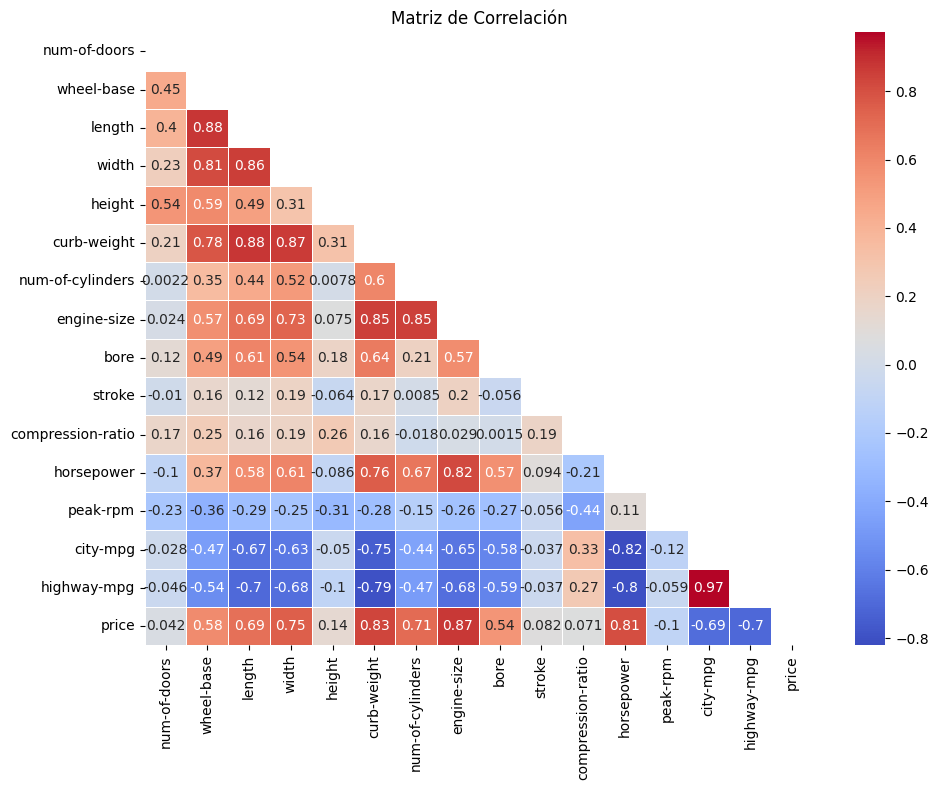

In [14]:
plt.figure(figsize=(10, 8))
corr = df.corr(numeric_only=True)
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(df.corr(numeric_only=True),mask = mask, annot=True, cmap='coolwarm', linewidths=0.5)
plt.title('Matriz de Correlación')
plt.tight_layout()
plt.show()

---
* SI BIEN LA MATRIZ SOLO CONTIENE VALORES NUMERICOS, VEMOS QUE HORSEPOWER, ENGINE-SIZE Y CURB-WEIGHT PRESENTAN UNA CORRELACION +0.8 AL PRECIO
* ESTE RESULTADO ME INDICARIA QUE SOLO USANDO VARIABLES NUMERICAS, SE PODRÍA OBTENER UN BUEN PREDICTOR DEL PRECIO DEL VEHICULO, SIN VARIABLES CATEGÓRICAS
---

## Parte 2: Preparación de Datos

* Selección de características importantes.
* Transformación de variables categóricas.
* División del conjunto de datos en entrenamiento y prueba.
* Escalado de características.

In [ ]:
# SE SELECCIONAN LAS COLUMNAS CATEGORICAS Y SUS VALUE_COUNT SE IMPRIMEN EN PANTALLA PARA TENERLOS DE DISPLAY
categoricas = df.select_dtypes(include=["object", "category"]).columns

for col in categoricas:
    print(f"--- Value Counts para la columna: {col} ---")
    print(df[col].value_counts())
    print("\n") 

--- Value Counts para la columna: make ---
make
toyota           32
nissan           18
mazda            17
mitsubishi       13
honda            13
subaru           12
volkswagen       12
volvo            11
peugot           11
dodge             9
mercedes-benz     8
bmw               8
plymouth          7
audi              6
saab              6
porsche           4
chevrolet         3
alfa-romero       3
jaguar            3
isuzu             2
renault           2
mercury           1
Name: count, dtype: int64


--- Value Counts para la columna: fuel-type ---
fuel-type
gas       181
diesel     20
Name: count, dtype: int64


--- Value Counts para la columna: aspiration ---
aspiration
std      165
turbo     36
Name: count, dtype: int64


--- Value Counts para la columna: body-style ---
body-style
sedan          94
hatchback      68
wagon          25
hardtop         8
convertible     6
Name: count, dtype: int64


--- Value Counts para la columna: drive-wheels ---
drive-wheels
fwd    118
rwd

### VARIABLES NUMERICAS VS TODAS LAS VARIABLES

* Se separa el workflow, creando un dataframe de solo columnas numericas, al que se aplica directamente cada modelo
* Se utilizara el dataframe con columnas categoricas para crear pipelines y ColumnTransformer

In [16]:
#crear DF solo con variables numericas
numDF = df.select_dtypes(include='number')

In [ ]:
#SE CREAN LAS VARIABLES Y SE ESCALAN
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# 2. Features y target
X = numDF.drop(columns=['price'])
y = numDF['price']

# 3. Train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 4. Estandarización
scaler = StandardScaler()
X_train_esc = scaler.fit_transform(X_train)
X_test_esc  = scaler.transform(X_test)

print(f'Features usadas: {X.shape[1]}')

Features usadas: 15


In [ ]:
#SE CREA EL PIPELINE DE PREPROCESADOR
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.compose import make_column_transformer, make_column_selector
from sklearn.pipeline import make_pipeline, Pipeline
from sklearn import set_config

set_config(display='diagram')

preprocesador_auto = make_column_transformer(
    (StandardScaler(),  make_column_selector(dtype_include=np.number)),
    (OneHotEncoder(drop='if_binary'),   make_column_selector(dtype_include=object)),
    remainder='drop'
)
preprocesador_auto

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('standardscaler', ...), ('onehotencoder', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``f

In [ ]:
#HACEMOS TRAIN SPLIT USANDO LAS VARIABLES CATEGORICAS
Xc = df.drop(columns=['price'])
yc = df['price']

print(f'Features usadas: {Xc.shape[1]}')

# 3. Train/test split
X_c_train, X_c_test, y_c_train, y_c_test = train_test_split(Xc, yc, test_size=0.2, random_state=42)

## Parte 3: Modelos de Regresión
### Regresión Lineal:

* Entrenamiento del modelo.
* Evaluación del rendimiento (MSE y R²).

In [20]:
#SIN PIPELINE Y SOLO USANDO VARIABLES NUMERICAS
from sklearn.linear_model import LinearRegression

LinReg = LinearRegression()
LinReg.fit(X_train_esc, y_train)

# 5. Predecir con el set de test
y_pred_lr = LinReg.predict(X_test_esc)

from sklearn.metrics import mean_squared_error, r2_score

mse  = mean_squared_error(y_test, y_pred_lr)
rmse = np.sqrt(mse)
r2   = r2_score(y_test, y_pred_lr)

print('📊 Evaluación del modelo')
print('─' * 50)
print(f'MSE:   {mse:>12,.0f}    USD^2')
print(f'RMSE:  {rmse:>12,.0f}    USD')
print(f'R²:    {r2:>12.4f}    ({r2*100:.1f}% de la varianza explicada)')


📊 Evaluación del modelo
──────────────────────────────────────────────────
MSE:     24,106,914    USD^2
RMSE:         4,910    USD
R²:          0.8030    (80.3% de la varianza explicada)


In [21]:
#USANDO PIPELINE Y VARIABLES CATEGORICAS
reg_pipeline = make_pipeline(
    preprocesador_auto,
    LinearRegression()
)

reg_pipeline.fit(X_c_train, y_c_train)
print(f'R²: {reg_pipeline.score(X_c_test, y_c_test):.4f}')

R²: 0.9356


---
* Se obtuvo una alta correlacion solo usando variables numericas. Y el r2 subio 0.13 al agregar las variables categoricas
* EL RMSE, me dice que puedo tener un error de cerca de 5 mil dolares en mis predicciones sin ocupar variables categoricas. 
* Considerando que la columna precio tiene un promedio del orden de 13 mil dolares con una desviacion estandar de cerca de 8 mil dolares, la regresion lineal aparece como un buen primer modelo para predecir el valor del precio de un automovil.

---

### K-Nearest Neighbors (KNN):

* Entrenamiento del modelo.
* Evaluación del rendimiento (MSE y R²).

In [ ]:
#SIN PIPELINE Y SOLO USANDO VARIABLES NUMERICAS
from sklearn.neighbors import KNeighborsRegressor

modelo_knn = KNeighborsRegressor(n_neighbors=3)
modelo_knn.fit(X_train_esc, y_train)

y_pred_knn = modelo_knn.predict(X_test_esc)


mse  = mean_squared_error(y_test, y_pred_knn)
rmse = np.sqrt(mse)
r2   = r2_score(y_test, y_pred_knn)

print('📊 Evaluación del modelo')
print('─' * 50)
print(f'MSE:   {mse:>12,.0f}    USD^2')
print(f'RMSE:  {rmse:>12,.0f}    USD')
print(f'R²:    {r2:>12.4f}    ({r2*100:.1f}% de la varianza explicada)')

📊 Evaluación del modelo
──────────────────────────────────────────────────
MSE:     38,669,542    USD^2
RMSE:         6,218    USD
R²:          0.6839    (68.4% de la varianza explicada)


In [23]:
#USANDO PIPELINE Y VARIABLES CATEGORICAS
knn_pipeline = make_pipeline(
    preprocesador_auto,
    KNeighborsRegressor(n_neighbors=3)
)

knn_pipeline.fit(X_c_train, y_c_train)
knn_pipeline

# UNA línea para predecir
print(f'R² test: {knn_pipeline.score(X_c_test, y_c_test):.4f}')

R² test: 0.6882


---
* El K-Neighbors es el peor modelo de los 3 para este caso. Su mayor valor ocurre en n=1. 
* Averiguando por internet, muestra que un n=1 mostraria overfitting, por lo que no seria util, sin embargo, el r2 disminuye mientras aumenta el N.
* Incluso incorporando las variables categoricas, no se observa un mejoramiento del modelo.
* Es el peor modelo y se sugiere descontinuar su uso para la predicción.
---

### Árbol de Decisión:

* Entrenamiento del modelo.
* Evaluación del rendimiento (MSE y R²).

In [ ]:
#SIN PIPELINE Y SOLO USANDO VARIABLES NUMERICAS
from sklearn.tree import DecisionTreeRegressor, plot_tree

modelo_arbol = DecisionTreeRegressor(max_depth=3, random_state=42)
modelo_arbol.fit(X_train, y_train)

y_pred_tree = modelo_arbol.predict(X_test)

mse  = mean_squared_error(y_test, y_pred_tree)
rmse = np.sqrt(mse)
r2   = r2_score(y_test, y_pred_tree)

print('📊 Evaluación del modelo')
print('─' * 50)
print(f'MSE:   {mse:>12,.0f}    USD^2')
print(f'RMSE:  {rmse:>12,.0f}    USD')
print(f'R²:    {r2:>12.4f}    ({r2*100:.1f}% de la varianza explicada)')

📊 Evaluación del modelo
──────────────────────────────────────────────────
MSE:     11,009,309    USD^2
RMSE:         3,318    USD
R²:          0.9100    (91.0% de la varianza explicada)


In [25]:
#USANDO PIPELINE Y VARIABLES CATEGORICAS
tree_pipeline = make_pipeline(
    preprocesador_auto,
    DecisionTreeRegressor(max_depth=7, random_state=42)
)

tree_pipeline.fit(X_c_train, y_c_train)
tree_pipeline

# UNA línea para predecir
print(f'R² test: {tree_pipeline.score(X_c_test, y_c_test):.4f}')

R² test: 0.9328


---
* Arboles de regresion fue el mejor modelo al usar solo variables numericas, y mejora un 0.23 al incorporar las variables categoricas.
* Presenta el menor RMSE de los 3 modelos, mostrando el menor error en sus predicciones.
---

## Parte 4: Benchmarking y Comparación de Modelos
### Comparación de Modelos:

* Comparar los resultados de los tres modelos en términos de MSE y R².
* Discusión sobre las diferencias en el rendimiento de los modelos.


### Modelos Individuales


In [26]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Lineal — necesita estandarización
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
sc = StandardScaler()
X_train_esc = sc.fit_transform(X_train)
X_test_esc  = sc.transform(X_test)

modelos = {
    'Regresión Lineal':      (LinearRegression(),               X_train_esc, X_test_esc),
    'KNN Regresor (k=3)':    (KNeighborsRegressor(n_neighbors=3), X_train_esc, X_test_esc),
    'Árbol (max_depth=3)':   (DecisionTreeRegressor(max_depth=3, random_state=42), X_train, X_test),
}

resultados = []
for nombre, (modelo, Xtr, Xte) in modelos.items():
    modelo.fit(Xtr, y_train)
    pred = modelo.predict(Xte)
    resultados.append({
        'Modelo': nombre,
        'R²': r2_score(y_test, pred),
        'MSE': mean_squared_error(y_test, pred),
        'RMSE': np.sqrt(mean_squared_error(y_test, pred))
    })

tabla = pd.DataFrame(resultados).set_index('Modelo').round(4)
tabla

,R²,MSE,RMSE
Modelo,,,
Regresión Lineal,0.8030,2.410691e+07,4909.8792
KNN Regresor (k=3),0.6839,3.866954e+07,6218.4839
Árbol (max_depth=3),0.9100,1.100931e+07,3318.0278


---
* Al comprar los 3 modelos, podemos afirmar que el mejor predictor de precios solo usando las variables numericas es el DecisionTreeRegressor, el cual tiene el mayor R2 (de 0.91) y el menor RMSE (de 3318).
* El peor modelo fue el KNN Regresor, cuyo maximo valor se obtenida con un n=1, y si aumentamos el valor de n, el R2 del modelo va disminuyendo. Tambien resulto en el modelo con el mayor error de los 3 analizados.
* Si bien la regresion lineal tuvo un R2 decente, el RMSE de ésta fue un 50% superior al obtenido por el DecisionTreeRegressor. 

---


### Comparación de Modelos con Pipelines



In [27]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Lineal — necesita estandarización
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
sc = StandardScaler()
X_train_esc = sc.fit_transform(X_train)
X_test_esc  = sc.transform(X_test)

modelos = {
    'Regresión Lineal':      (reg_pipeline, X_c_train, X_c_test),
    'KNN Regresor (k=3)':    (knn_pipeline, X_c_train, X_c_test),
    'Árbol (max_depth=7)':   (tree_pipeline, X_c_train, X_c_test),
}

resultados = []
for nombre, (modelo, Xtr, Xte) in modelos.items():
    modelo.fit(Xtr, y_train)
    pred = modelo.predict(Xte)
    resultados.append({
        'Modelo': nombre,
        'R²': r2_score(y_test, pred),
        'MSE': mean_squared_error(y_test, pred),
        'RMSE': np.sqrt(mean_squared_error(y_test, pred))
    })

tabla_pipeline = pd.DataFrame(resultados).set_index('Modelo').round(4)
tabla_pipeline

,R²,MSE,RMSE
Modelo,,,
Regresión Lineal,0.9356,7.874282e+06,2806.1151
KNN Regresor (k=3),0.6882,3.814203e+07,6175.9235
Árbol (max_depth=7),0.9328,8.220675e+06,2867.1720


---
* Al incorporar las variables categoricas al analisis, vemos que la regresion lineal es el modelo cuya mejora fue mayor, y se equipara a los resultados del Arbol de Decision.
* Considero que tanto regresion lineal y el arbol de decision son los mejores modelos para la predicción de precios de autos. Si nos ponemos estrictor y consideramos un R2 mayor en 0.028 y un RMSE menor en 61.06, la regresion lineal debiese ser el mejor modelo en este caso.
* El Regresor KNN, es el peor modelo de los 3, con el menor R2 y el mayor RMSE (practicamente duplica el valor de los otros dos modelos).
---

## Tareas Adicionales y Desafíos

### Desafíos Adicionales:

* Optimización de Modelos: Usar GridSearchCV para optimizar los hiperparámetros de KNN y el Árbol de Decisión.
* Feature Engineering: Crear nuevas características basadas en las existentes para mejorar el rendimiento del modelo.
* Validación Cruzada: Implementar validación cruzada para evaluar la estabilidad de los modelos.

---
### GridSearch para optimizar KNN
---

In [28]:
from sklearn.model_selection import GridSearchCV

# Definir el modelo base + grilla de hiperparámetros a probar
modelo_knn = KNeighborsRegressor()

param_grid = {
    'n_neighbors': [1, 3, 5, 7, 9, 10, 11, 13, 15],
    'weights':    ['uniform', 'distance']
}

# GridSearch con 3-fold CV (3 splits dentro del train) — total: 3×3×3 = 27 entrenamientos
grid = GridSearchCV(
    estimator=modelo_knn,
    param_grid=param_grid,
    cv=3,                  # 3-fold CV
    scoring='r2',          # métrica a optimizar
    n_jobs=-1,             # paralelización
    verbose=1
)

grid.fit(X_train, y_train)

print(f'\n🏆 Mejores hiperparámetros: {grid.best_params_}')
print(f'   Mejor R² (CV):           {grid.best_score_:.4f}')
print(f'   R² en test:              {grid.score(X_test, y_test):.4f}')


Fitting 3 folds for each of 18 candidates, totalling 54 fits

🏆 Mejores hiperparámetros: {'n_neighbors': 5, 'weights': 'distance'}
   Mejor R² (CV):           0.7639
   R² en test:              0.8278


---
* El modelo observa una mejora sustantiva al comprar diversos neighbors y tambien al comparar la ponderacion de la distancia en el modelo.
* Si bien, al trabajar en el modelo, el R2 siempre se mantuvo en 0.68, al cambiar los parametros de éste, se pudo obtener un r2 de 0.76.
* Al comienzo, decidio que KNN no deberia ser utilizado en este caso, los nuevos parametros permiten re-evaluar el modelo, desechando la decision inicial. 
---

---
### GridSearch para optimizar Arbol de Decisión
---

In [30]:
from sklearn.model_selection import GridSearchCV

# Definir el modelo base + grilla de hiperparámetros a probar
modelo_arbol = DecisionTreeRegressor()

param_grid = {
    'max_depth': [1,2,3,4,5,6,7,8,9,10, None],
    'criterion':    ['squared_error', 'friedman_mse', 'absolute_error', 'poisson']
}

# GridSearch con 3-fold CV (3 splits dentro del train) — total: 3×3×3 = 27 entrenamientos
grid = GridSearchCV(
    estimator=modelo_arbol,
    param_grid=param_grid,
    cv=3,                  # 3-fold CV
    scoring='r2',          # métrica a optimizar
    n_jobs=-1,             # paralelización
    verbose=1
)

grid.fit(X_train, y_train)

print(f'\n🏆 Mejores hiperparámetros: {grid.best_params_}')
print(f'   Mejor R² (CV):           {grid.best_score_:.4f}')
print(f'   R² en test:              {grid.score(X_test, y_test):.4f}')


Fitting 3 folds for each of 44 candidates, totalling 132 fits

🏆 Mejores hiperparámetros: {'criterion': 'poisson', 'max_depth': 6}
   Mejor R² (CV):           0.8213
   R² en test:              0.8839


---
* GridSearchCV me indica que el mejor R2 es de 0.82, mientras que al aplicar directamente el modelo con el 100% de los datos, logro obtener sobre 0.9.
* Averiguando esto puede ser explicado por la forma en que gridsearch funciona con cv=3, como tambien que es posible que el modelo creado tenga cierto overtfitting de los datos
* Incluso para lograr el mejor R2, utilizo otro criterio al estandar y con una profundidad levemente menor a la del modelo trabajado anteriormente
* Es posible que el modelo de arbol se encuentre entonces, con overfit en primer lugar, y por eso logra los menores valores de RMSE con un alto R2. 
---